In [ ]:
#Cell 1: Switching MuJoCo's rendering backend to EGL
import os
os.environ["MUJOCO_GL"] = "egl"
os.environ["PYOPENGL_PLATFORM"] = "egl"

In [ ]:
## Cell 2: Install
!apt-get update -qq && apt-get install -qq -y libegl1 libgl1 libglx-mesa0 libosmesa6 2>&1 | tail -5
%pip install -q gymnasium-robotics mujoco "gymnasium[mujoco]" stable-baselines3 pettingzoo torch imageio imageio-ffmpeg

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
## Cell 3: Imports

import importlib.metadata as metadata
packages = ["gymnasium_robotics", "gymnasium", "pettingzoo", "mujoco", "stable_baselines3", "torch"]
for package in packages:
    print(f"{package}: {metadata.version(package)}")

import imageio.v2 as imageio
from IPython.display import Video, display

from gymnasium_robotics import mamujoco_v1
import numpy as np
np.set_printoptions(precision=3, suppress=True)

gymnasium_robotics: 1.4.2
gymnasium: 1.3.0
pettingzoo: 1.26.1
mujoco: 3.10.0
stable_baselines3: 2.9.0
torch: 2.11.0+cpu


In [ ]:
## Cell 4: Exploration Code
## Create 2-agent HalfCheetah and reset the environment
env = mamujoco_v1.parallel_env("HalfCheetah", "2x3")

observations, infos = env.reset(seed=42)

for agent in env.agents:
  print(f"Agent: {agent}")
  print(f"  Observation: {observations[agent]}")
  print(f"  Info: {infos[agent]}")
  print("Observation space:", env.observation_space(agent))
  print("Action space:", env.action_space(agent))

## Inspect the current global state
global_state = env.state()
print(f"type of global state: {type(global_state)}")
print(f"shape of global state: {global_state.shape}")
print(f"shape of global data type: {global_state.dtype}")
print(f"values of global state: {global_state}")

## Compare global and local information

mapped_observations = env.map_global_state_to_local_observations(global_state)

for agent in env.agents:
  print(f"agent: {agent}")
  print(f"  Mapped and local observation: {mapped_observations[agent], observations[agent]}")
  print(f"  local shape: {mapped_observations[agent].shape}")


Agent: agent_0
  Observation: [ 0.095  0.047 -0.081  0.113  0.039  0.007  0.052 -0.012  0.072 -0.085
  0.088  0.078]
  Info: {'x_position': np.float64(0.05479120971119267)}
Observation space: Box(-inf, inf, (12,), float64)
Action space: Box(-1.0, 1.0, (3,), float32)
Agent: agent_1
  Observation: [-0.074 -0.096  0.057  0.037  0.052 -0.086  0.039 -0.012  0.072 -0.085
  0.088  0.078]
  Info: {'x_position': np.float64(0.05479120971119267)}
Observation space: Box(-inf, inf, (12,), float64)
Action space: Box(-1.0, 1.0, (3,), float32)
type of global state: <class 'numpy.ndarray'>
shape of global state: (17,)
shape of global data type: float64
values of global state: [-0.012  0.072  0.039 -0.081  0.095  0.052  0.057 -0.074 -0.085  0.088
  0.078  0.007  0.113  0.047 -0.086  0.037 -0.096]
agent: agent_0
  Mapped and local observation: (array([ 0.095,  0.047, -0.081,  0.113,  0.039,  0.007,  0.052, -0.012,
        0.072, -0.085,  0.088,  0.078]), array([ 0.095,  0.047, -0.081,  0.113,  0.039,  0.

In [ ]:
## Cell 5: Sanity check -- take one random step (Kate's original check)
actions = {agent: env.action_space(agent).sample() for agent in env.agents}
observations, rewards, terminations, truncations, infos = env.step(actions)

for agent in actions:
    print(f"agent: {agent}")
    print("action:", actions[agent])
    print("reward:", rewards[agent])
    print("terminated:", terminations[agent])
    print("truncated:", truncations[agent])
    print("observation:", observations[agent])
    print("info:", infos[agent])

## Running episode + video rendering follows in a later cell (bottom of cell 14)

agent: agent_0
action: [-0.884  0.328 -0.741]
reward: -1.0932032250888402
terminated: False
truncated: False
observation: [-0.235 -8.087  0.181  4.958 -0.264 -7.907 -0.202 -0.028  0.071 -1.039
 -0.579  0.128]
info: {'x_position': np.float64(0.014005211044374716), 'x_velocity': np.float64(-0.815719973336359), 'reward_forward': np.float64(-0.815719973336359), 'reward_ctrl': np.float64(-0.27748325175248106)}
agent: agent_1
action: [-0.542  0.545 -0.864]
reward: -1.0932032250888402
terminated: False
truncated: False
observation: [-0.267 -5.241  0.28   5.009 -0.202 -6.489 -0.264 -0.028  0.071 -1.039
 -0.579  0.128]
info: {'x_position': np.float64(0.014005211044374716), 'x_velocity': np.float64(-0.815719973336359), 'reward_forward': np.float64(-0.815719973336359), 'reward_ctrl': np.float64(-0.27748325175248106)}


In [ ]:
#Cell 6: Networks -- per-agent actors + centralized critic
#~5s runtime
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def mlp(sizes, activation=nn.Tanh, output_activation=nn.Identity):
    layers = []
    for i in range(len(sizes) - 1):
        act = activation if i < len(sizes) - 2 else output_activation
        layers += [nn.Linear(sizes[i], sizes[i+1]), act()]
    return nn.Sequential(*layers)

class GaussianActor(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=(64, 64)):
        super().__init__()
        self.mu_net = mlp([obs_dim, *hidden, act_dim])
        self.log_std = nn.Parameter(-0.5 * torch.ones(act_dim))

    def forward(self, obs):
        mu = self.mu_net(obs)
        std = torch.exp(self.log_std)
        dist = torch.distributions.Normal(mu, std)
        return dist

class CentralizedCritic(nn.Module):
    def __init__(self, global_obs_dim, hidden=(64, 64)):
        super().__init__()
        self.v_net = mlp([global_obs_dim, *hidden, 1])

    def forward(self, global_obs):
        return self.v_net(global_obs).squeeze(-1)

# Instantiate: one actor per agent, one shared centralized critic
obs_dim = env.observation_space("agent_0").shape[0]   # 11
act_dim = env.action_space("agent_0").shape[0]        # 3
global_obs_dim = 17

actors = {agent: GaussianActor(obs_dim, act_dim).to(device) for agent in env.agents}
critic = CentralizedCritic(global_obs_dim).to(device)

actor_params = [p for a in actors.values() for p in a.parameters()]
actor_optimizer = torch.optim.Adam(actor_params, lr=3e-4)
critic_optimizer = torch.optim.Adam(critic.parameters(), lr=1e-3)

print("Actor param count (per agent):", sum(p.numel() for p in actors["agent_0"].parameters()))
print("Critic param count:", sum(p.numel() for p in critic.parameters()))

Actor param count (per agent): 5190
Critic param count: 5377


In [ ]:
#Cell 7: Rollout buffer + GAE
class RolloutBuffer:
    def __init__(self, size, obs_dim, act_dim, global_obs_dim, n_agents, gamma=0.99, lam=0.95):
        self.obs = {a: np.zeros((size, obs_dim), dtype=np.float32) for a in range(n_agents)}
        self.acts = {a: np.zeros((size, act_dim), dtype=np.float32) for a in range(n_agents)}
        self.logp = {a: np.zeros(size, dtype=np.float32) for a in range(n_agents)}
        self.rews = np.zeros(size, dtype=np.float32)       # shared reward (HalfCheetah gives identical reward to both)
        self.global_obs = np.zeros((size, global_obs_dim), dtype=np.float32)
        self.vals = np.zeros(size, dtype=np.float32)
        self.gamma, self.lam = gamma, lam
        self.ptr, self.max_size = 0, size

    def store(self, obs_dict, act_dict, logp_dict, rew, global_obs, val):
        for i, a in enumerate(obs_dict.keys()):
            self.obs[i][self.ptr] = obs_dict[a]
            self.acts[i][self.ptr] = act_dict[a]
            self.logp[i][self.ptr] = logp_dict[a]
        self.rews[self.ptr] = rew
        self.global_obs[self.ptr] = global_obs
        self.vals[self.ptr] = val
        self.ptr += 1

    def compute_advantages(self, last_val=0.0):
        adv = np.zeros(self.max_size, dtype=np.float32)
        last_gae = 0.0
        for t in reversed(range(self.max_size)):
            next_val = self.vals[t+1] if t < self.max_size - 1 else last_val
            delta = self.rews[t] + self.gamma * next_val - self.vals[t]
            last_gae = delta + self.gamma * self.lam * last_gae
            adv[t] = last_gae
        returns = adv + self.vals
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)
        return adv, returns

    def reset(self):
        self.ptr = 0

In [ ]:
#Cell 8: Rollout collection
def collect_rollout(env, actors, critic, buffer, rollout_steps):
    obs, info = env.reset()
    agent_list = list(env.agents)  # cache once, right after reset
    ep_returns, ep_ret = [], 0.0

    for t in range(rollout_steps):
        act_dict, logp_dict = {}, {}
        with torch.no_grad():
            for agent in agent_list:
                obs_t = torch.as_tensor(obs[agent], dtype=torch.float32, device=device)
                dist = actors[agent](obs_t)
                action = dist.sample()
                logp = dist.log_prob(action).sum(-1)
                act_dict[agent] = action.cpu().numpy()
                logp_dict[agent] = logp.item()

            global_obs = env.unwrapped.map_local_observations_to_global_state(obs)
            global_obs_t = torch.as_tensor(global_obs, dtype=torch.float32, device=device)
            val = critic(global_obs_t).item()

        next_obs, rewards, terms, truncs, infos = env.step(act_dict)
        rew = rewards[agent_list[0]]  # shared reward, using cached agent name
        buffer.store(obs, act_dict, logp_dict, rew, global_obs, val)
        ep_ret += rew

        done = all(terms.values()) or all(truncs.values())
        if done:
            obs, info = env.reset()
            agent_list = list(env.agents)  # re-cache after reset
            ep_returns.append(ep_ret)
            ep_ret = 0.0
        else:
            obs = next_obs

    with torch.no_grad():
        global_obs = env.unwrapped.map_local_observations_to_global_state(obs)
        last_val = critic(torch.as_tensor(global_obs, dtype=torch.float32, device=device)).item()

    return last_val, ep_returns

In [ ]:
#Cell 9: PPO update step
def ppo_update(buffer, actors, critic, actor_optimizer, critic_optimizer,
               last_val, clip_ratio=0.2, train_iters=10):
    adv, returns = buffer.compute_advantages(last_val)
    adv_t = torch.as_tensor(adv, dtype=torch.float32, device=device)
    ret_t = torch.as_tensor(returns, dtype=torch.float32, device=device)
    global_obs_t = torch.as_tensor(buffer.global_obs, dtype=torch.float32, device=device)

    for _ in range(train_iters):
        # Critic update
        critic_optimizer.zero_grad()
        values = critic(global_obs_t)
        critic_loss = ((values - ret_t) ** 2).mean()
        critic_loss.backward()
        critic_optimizer.step()

        # Actor updates (independent per agent)
        actor_optimizer.zero_grad()
        total_actor_loss = 0.0
        for i, agent in enumerate(env.agents):
            obs_t = torch.as_tensor(buffer.obs[i], dtype=torch.float32, device=device)
            act_t = torch.as_tensor(buffer.acts[i], dtype=torch.float32, device=device)
            old_logp_t = torch.as_tensor(buffer.logp[i], dtype=torch.float32, device=device)

            dist = actors[agent](obs_t)
            logp = dist.log_prob(act_t).sum(-1)
            ratio = torch.exp(logp - old_logp_t)
            clip_adv = torch.clamp(ratio, 1 - clip_ratio, 1 + clip_ratio) * adv_t
            actor_loss = -torch.min(ratio * adv_t, clip_adv).mean()
            total_actor_loss += actor_loss

        total_actor_loss.backward()
        actor_optimizer.step()

    return critic_loss.item(), total_actor_loss.item()

In [ ]:
#Cell 10: Training loop
#Note: took ~9 minutes to run this cell
rollout_steps = 2048
n_epochs = 200
buffer = RolloutBuffer(rollout_steps, obs_dim, act_dim, global_obs_dim, n_agents=2)

history = {"epoch": [], "avg_return": [], "critic_loss": [], "actor_loss": []}

for epoch in range(n_epochs):
    buffer.reset()
    last_val, ep_returns = collect_rollout(env, actors, critic, buffer, rollout_steps)
    critic_loss, actor_loss = ppo_update(buffer, actors, critic, actor_optimizer, critic_optimizer, last_val)

    avg_ret = np.mean(ep_returns) if ep_returns else np.nan
    history["epoch"].append(epoch)
    history["avg_return"].append(avg_ret)
    history["critic_loss"].append(critic_loss)
    history["actor_loss"].append(actor_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:4d} | episodes: {len(ep_returns):3d} | avg return: {avg_ret:8.2f} | "
              f"critic loss: {critic_loss:.3f} | actor loss: {actor_loss:.3f}")

Epoch    0 | episodes:   2 | avg return:  -303.97 | critic loss: 47.210 | actor loss: -0.025
Epoch   10 | episodes:   2 | avg return:  -196.24 | critic loss: 13.487 | actor loss: -0.018
Epoch   20 | episodes:   2 | avg return:  -121.18 | critic loss: 15.183 | actor loss: -0.016
Epoch   30 | episodes:   2 | avg return:  -106.19 | critic loss: 18.707 | actor loss: -0.016
Epoch   40 | episodes:   2 | avg return:  -162.07 | critic loss: 28.367 | actor loss: -0.014
Epoch   50 | episodes:   2 | avg return:  -213.95 | critic loss: 27.298 | actor loss: -0.012
Epoch   60 | episodes:   2 | avg return:  -255.35 | critic loss: 26.050 | actor loss: -0.015
Epoch   70 | episodes:   2 | avg return:  -178.15 | critic loss: 46.125 | actor loss: -0.017
Epoch   80 | episodes:   2 | avg return:   -21.04 | critic loss: 27.945 | actor loss: -0.019
Epoch   90 | episodes:   2 | avg return:     7.99 | critic loss: 22.603 | actor loss: -0.019
Epoch  100 | episodes:   2 | avg return:   177.86 | critic loss: 26.22

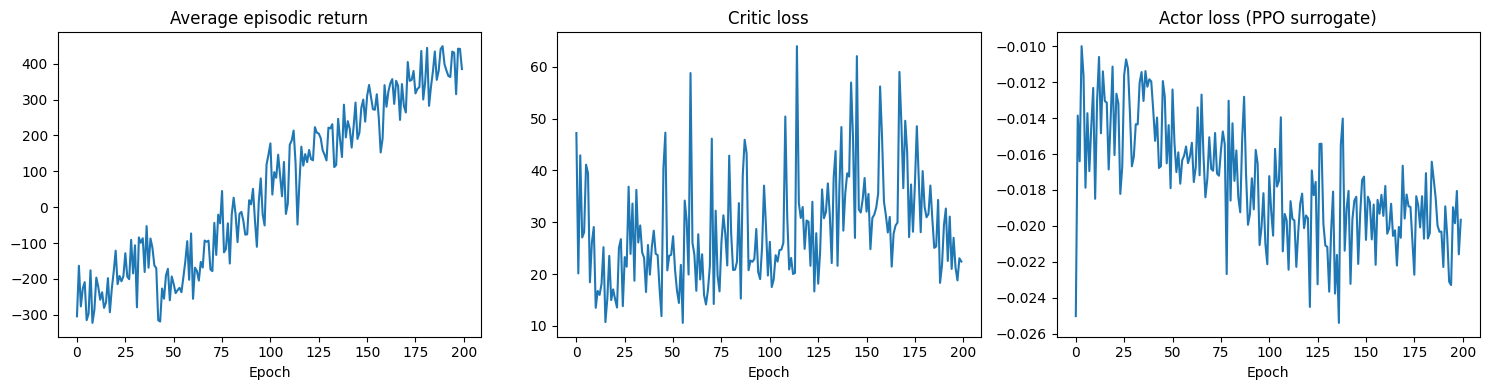

In [ ]:
#Cell 11: Plotting cell
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["epoch"], history["avg_return"])
axes[0].set_title("Average episodic return")
axes[0].set_xlabel("Epoch")

axes[1].plot(history["epoch"], history["critic_loss"])
axes[1].set_title("Critic loss")
axes[1].set_xlabel("Epoch")

axes[2].plot(history["epoch"], history["actor_loss"])
axes[2].set_title("Actor loss (PPO surrogate)")
axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.show()

In [ ]:
# Claude fix, I didn't change this so im not sure why it didnt work
with torch.no_grad():
    for t in range(1000):
        frames.append(render_env.render())
        act_dict = {}

        for agent in agent_list:
            obs_t = torch.as_tensor(
                obs_eval[agent],
                dtype=torch.float32,
                device=device
            )

            # Add the missing 12th input
            w_eval = torch.tensor(
                [0.5],
                dtype=torch.float32,
                device=device
            )

            actor_input = torch.cat(
                [obs_t, w_eval],
                dim=-1
            )

            dist = actors[agent](actor_input)

            act_dict[agent] = dist.mean.cpu().numpy()

        obs_eval, rewards, terms, truncs, infos = render_env.step(act_dict)

        if all(terms.values()) or all(truncs.values()):
            break

Checkpoint 1: Basic Install & Training Checks Complete

In [ ]:
# NEW CELL 13: Save and load checkpoints for the k=0 baseline to Google Drive to
# avoid wiping on disconnect from runtime (because I really don't want to wait
# 40 minutes every time I load this notebook to get to Cell 18). Can use
# this load cell to restore in a future session without retraining from scratch.

# Mount Google Drive for persistent storage
from google.colab import drive
drive.mount('/content/drive')

checkpoint_dir = "/content/drive/MyDrive/moma_ac_checkpoints"
import os
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_path = f"{checkpoint_dir}/k0_baseline.pt"

# Save
torch.save({
    "agent_0": actors["agent_0"].state_dict(),
    "agent_1": actors["agent_1"].state_dict(),
    "critic": critic.state_dict(),
    "history": history,  # save training curve data alongside weights
}, checkpoint_path)

print(f"Saved checkpoint to {checkpoint_path}")

# Load (run this instead of retraining in a future session)
# checkpoint = torch.load(checkpoint_path, map_location=device)
# actors["agent_0"].load_state_dict(checkpoint["agent_0"])
# actors["agent_1"].load_state_dict(checkpoint["agent_1"])
# critic.load_state_dict(checkpoint["critic"])
# history = checkpoint["history"]
# print("Checkpoint loaded")

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# NEW CELL 14: Decompose HalfCheetah's reward into (velocity, -control_cost) components

#The env's default reward is a fixed blend: forward_velocity - ctrl_cost_weight * sum(action^2).
# To make this w-conditioned, we need the two components separately so we can
# recombine them as w[0]*velocity - w[1]*control_cost instead of using the env's
# fixed blend. MaMuJoCo's info dict exposes x_velocity directly (confirmed in
# Kate's exploration); control cost we compute ourselves from the action vector,
# matching HalfCheetah's default ctrl_cost_weight (0.1) so the two components
# are on a comparable scale to the original reward.

CTRL_COST_WEIGHT = 0.1  # matches Gymnasium HalfCheetah-v4/v5 default

def compute_reward_components(rewards, infos, act_dict, agent_list):
    """
    Returns per-agent (velocity_term, control_cost_term) as plain floats.
    velocity_term is shared across agents (whole-body forward velocity).
    control_cost_term is computed per-agent from that agent's own actions,
    so each leg is only "penalized" for its own effort, not the other leg's.
    """
    # x_velocity is identical across agents (whole-body quantity) — grab from either
    velocity = infos[agent_list[0]]["x_velocity"]

    components = {}
    for agent in agent_list:
        ctrl_cost = CTRL_COST_WEIGHT * np.sum(np.square(act_dict[agent]))
        components[agent] = (velocity, ctrl_cost)
    return components

# Quick sanity check against the env's own reward, using a random step
obs, info = env.reset(seed=0)
agent_list = list(env.agents)
act_dict = {agent: env.action_space(agent).sample() for agent in agent_list}
obs, rewards, terms, truncs, infos = env.step(act_dict)

components = compute_reward_components(rewards, infos, act_dict, agent_list)
for agent in agent_list:
    vel, ctrl = components[agent]
    reconstructed = vel - ctrl
    print(f"{agent}: env reward={rewards[agent]:.4f} | "
          f"reconstructed (vel - ctrl)={reconstructed:.4f} | "
          f"velocity={vel:.4f}, ctrl_cost={ctrl:.4f}")

agent_0: env reward=0.5699 | reconstructed (vel - ctrl)=0.6759 | velocity=0.7351, ctrl_cost=0.0592
agent_1: env reward=0.5699 | reconstructed (vel - ctrl)=0.6292 | velocity=0.7351, ctrl_cost=0.1059


In [ ]:
# MODIFIED HAshcraft Cell 15:

W_DIM = 2  # (velocity_weight, energy_weight)

# V changed from the original V #
class IBGaussianActorW(nn.Module):
    def __init__(
        self,
        obs_dim,
        w_dim,
        act_dim,
        latent_dim=8,
        hidden=(64, 64)
    ):
        super().__init__()

        input_dim = obs_dim + w_dim

        # Processes observation + preference vector
        self.encoder = mlp(
            [input_dim, *hidden],
            output_activation=nn.Tanh
        )

        # Parameters of p(z | s, w)
        self.z_mu = nn.Linear(hidden[-1], latent_dim)
        self.z_logvar = nn.Linear(hidden[-1], latent_dim)

        # Converts compressed z into action mean
        self.action_mu_net = mlp(
            [latent_dim, *hidden, act_dim]
        )

        self.log_std = nn.Parameter(
            -0.5 * torch.ones(act_dim)
        )

    def forward(self, obs, w, sample_z=True):
        x = torch.cat([obs, w], dim=-1)

        h = self.encoder(x)

        z_mu = self.z_mu(h)
        z_logvar = self.z_logvar(h).clamp(-10, 5)

        if sample_z:
            z_std = torch.exp(0.5 * z_logvar)
            epsilon = torch.randn_like(z_std)
            z = z_mu + z_std * epsilon
        else:
            # Noise-suspended SNI version
            z = z_mu

        action_mu = self.action_mu_net(z)
        action_std = torch.exp(self.log_std)

        dist = torch.distributions.Normal(
            action_mu,
            action_std
        )

        return dist, z_mu, z_logvar
        # ^ changed from the original ^ #

# Re-instantiate actors with w-conditioning (critic is unchanged, still sees
# only global state, no w, per the plan to keep the critic's role fixed)

# V changed from the original V #
actors_w = {agent: IBGaussianActorW(obs_dim,W_DIM,act_dim,latent_dim=8).to(device)for agent in env.agents} #
actor_w_params = [p for a in actors_w.values() for p in a.parameters()]
actor_w_optimizer = torch.optim.Adam(actor_w_params, lr=3e-4)
# ^ changed from the original ^ #

print("W-conditioned actor param count (per agent):",
      sum(p.numel() for p in actors_w["agent_0"].parameters()))


def collect_rollout_w(env, actors, critic, buffer, rollout_steps, w):
    """
    Same as collect_rollout, but:
    - concatenates fixed w onto each agent's observation before the actor call
    - computes reward as w[0]*velocity - w[1]*ctrl_cost instead of env's reward
    w exists as numpy array of shape (W_DIM,); fixed for this call.
    """
    obs, info = env.reset()
    agent_list = list(env.agents)
    ep_returns, ep_ret = [], 0.0
    w_t = torch.as_tensor(w, dtype=torch.float32, device=device)

    for t in range(rollout_steps):
        act_dict, logp_dict = {}, {}
        with torch.no_grad():
            for agent in agent_list:
                obs_t = torch.as_tensor(obs[agent], dtype=torch.float32, device=device)

                # V changed from the original V #
                dist, _, _ = actors[agent](obs_t, w_t,sample_z=False)
                action = dist.sample()
                logp = dist.log_prob(action).sum(-1)
                # ^ changed from the original ^ #

                act_dict[agent] = action.cpu().numpy()
                logp_dict[agent] = logp.item()

            global_obs = env.state()  # adopted from Kate's notebook, replaces manual mapping
            global_obs_t = torch.as_tensor(global_obs, dtype=torch.float32, device=device)
            val = critic(global_obs_t).item()

        next_obs, rewards, terms, truncs, infos = env.step(act_dict)

        # Recompute reward from components instead of using env's blended reward
        components = compute_reward_components(rewards, infos, act_dict, agent_list)
        velocity, ctrl_cost = components[agent_list[0]]  # velocity shared; use agent_0's ctrl cost as representative
        rew = w[0] * velocity - w[1] * ctrl_cost

        buffer.store(obs, act_dict, logp_dict, rew, global_obs, val)
        ep_ret += rew

        done = all(terms.values()) or all(truncs.values())
        if done:
            obs, info = env.reset()
            agent_list = list(env.agents)
            ep_returns.append(ep_ret)
            ep_ret = 0.0
        else:
            obs = next_obs

    with torch.no_grad():
        global_obs = env.state()
        last_val = critic(torch.as_tensor(global_obs, dtype=torch.float32, device=device)).item()

    return last_val, ep_returns

W-conditioned actor param count (per agent): 11094


In [ ]:
# V changed from the original V #
# MODIFIED HAshcraft (ADDED) Cell 16:
def latent_kl_loss(z_mu, z_logvar):
    """
    KL divergence between:
        p(z | s, w) = N(mu, variance)
    and:
        q(z) = N(0, I)
    """
    kl_per_sample = -0.5 * torch.sum(
        1
        + z_logvar
        - z_mu.pow(2)
        - z_logvar.exp(),
        dim=-1
    )

    return kl_per_sample.mean()
    # ^ changed from the original ^ #

In [ ]:
# # MODIFIED HAshcraft (ORIGINAL) NEW CELL 16: Patch to ppo_update (now Cell 9) for w-conditioning
# V changed from the original V #
def ppo_update_w(buffer,actors,critic,actor_optimizer,critic_optimizer,last_val,w,
                 clip_ratio=0.2,
                 train_iters=10,
                 sni_lambda=0.5,
                 beta_ib=1e-4
):
    adv, returns = buffer.compute_advantages(last_val)
    adv_t = torch.as_tensor(adv,dtype=torch.float32,device=device)
    ret_t = torch.as_tensor(returns,dtype=torch.float32,device=device)
    global_obs_t = torch.as_tensor(buffer.global_obs,dtype=torch.float32,device=device)
    w_t = torch.as_tensor(w,dtype=torch.float32,device=device).unsqueeze(0).expand(
        len(buffer.obs[0]),-1)

    for _ in range(train_iters):

        # Critic update stays unchanged
        critic_optimizer.zero_grad()
        values = critic(global_obs_t)
        critic_loss = ((values - ret_t) ** 2).mean()
        critic_loss.backward()
        critic_optimizer.step()

        # Actor update
        actor_optimizer.zero_grad()
        total_actor_loss = 0.0
        total_kl_loss = 0.0
        for i, agent in enumerate(env.agents):
            obs_t = torch.as_tensor(buffer.obs[i],dtype=torch.float32,device=device)
            act_t = torch.as_tensor(buffer.acts[i],dtype=torch.float32,device=device)
            old_logp_t = torch.as_tensor(buffer.logp[i],dtype=torch.float32,device=device)

            # Deterministic latent pass
            dist_det, _, _ = actors[agent](obs_t,w_t,sample_z=False)
            logp_det = dist_det.log_prob(act_t).sum(-1)
            ratio_det = torch.exp(logp_det - old_logp_t)
            clipped_det = torch.clamp(ratio_det,1 - clip_ratio,1 + clip_ratio)
            loss_det = -torch.min(ratio_det * adv_t,clipped_det * adv_t).mean()

            # Stochastic latent pass
            dist_stoch, z_mu, z_logvar = actors[agent](obs_t,w_t,sample_z=True)
            logp_stoch = dist_stoch.log_prob(act_t).sum(-1)
            ratio_stoch = torch.exp(logp_stoch - old_logp_t)
            clipped_stoch = torch.clamp(ratio_stoch,1 - clip_ratio,1 + clip_ratio)
            loss_stoch = -torch.min(ratio_stoch * adv_t,clipped_stoch * adv_t).mean()

            # SNI mixture from Equation 7
            sni_loss = (sni_lambda * loss_det + (1 - sni_lambda) * loss_stoch)

            # IB regularization from Equations 9–12
            kl_loss = latent_kl_loss(z_mu,z_logvar)
            actor_loss = (sni_loss + beta_ib * kl_loss)
            total_actor_loss += actor_loss
            total_kl_loss += kl_loss.detach()
        total_actor_loss.backward()
        torch.nn.utils.clip_grad_norm_(actor_w_params,max_norm=0.5)
        actor_optimizer.step()

    return (critic_loss.item(),total_actor_loss.item(),total_kl_loss.item())
# ^ changed from the original ^ #

[w=[0.5 0.5]] Epoch    0 | episodes:   2 | avg return:  -127.09 | critic loss: 17.981 | actor loss: 0.001
[w=[0.5 0.5]] Epoch   10 | episodes:   2 | avg return:   -65.07 | critic loss: 6.831 | actor loss: 0.004
[w=[0.5 0.5]] Epoch   20 | episodes:   2 | avg return:   -62.17 | critic loss: 3.871 | actor loss: -0.001
[w=[0.5 0.5]] Epoch   30 | episodes:   2 | avg return:   -51.49 | critic loss: 2.285 | actor loss: -0.001
[w=[0.5 0.5]] Epoch   40 | episodes:   2 | avg return:   -34.08 | critic loss: 2.645 | actor loss: -0.006
[w=[0.5 0.5]] Epoch   50 | episodes:   2 | avg return:   -41.18 | critic loss: 2.868 | actor loss: -0.001
[w=[0.5 0.5]] Epoch   60 | episodes:   2 | avg return:    12.20 | critic loss: 2.681 | actor loss: -0.006
[w=[0.5 0.5]] Epoch   70 | episodes:   2 | avg return:    17.43 | critic loss: 2.617 | actor loss: -0.001
[w=[0.5 0.5]] Epoch   80 | episodes:   2 | avg return:    26.22 | critic loss: 2.422 | actor loss: -0.005
[w=[0.5 0.5]] Epoch   90 | episodes:   2 | avg 

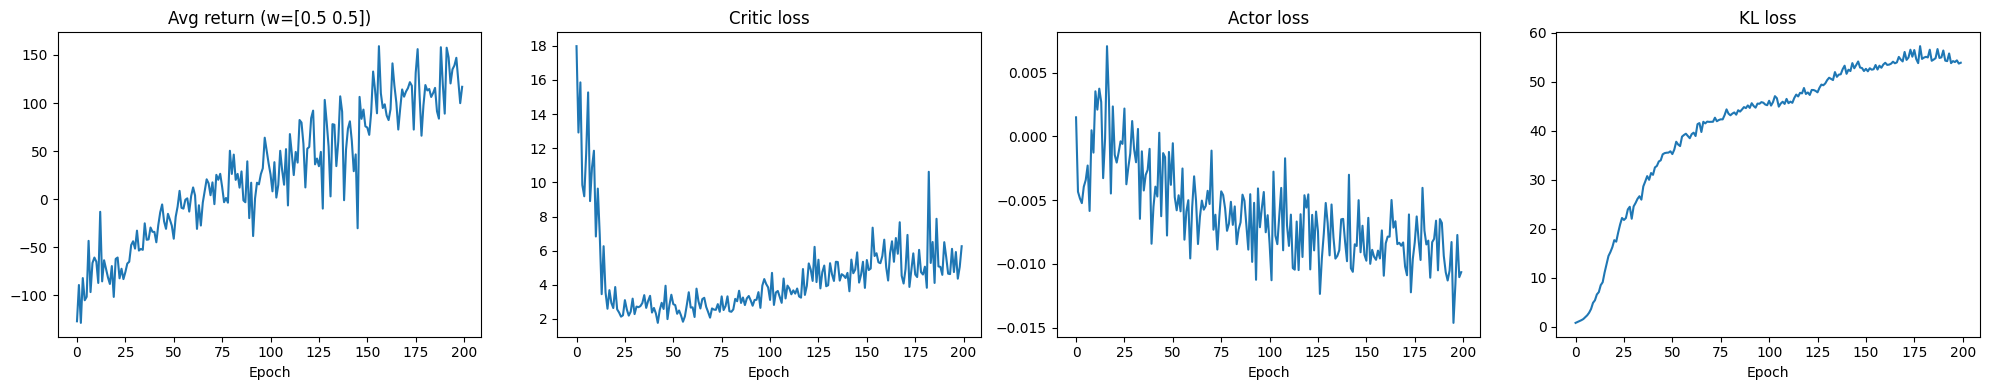

In [ ]:
# NEW CELL 17: Train with a fixed preference vector to confirm the w-conditioned
# pipeline still learns. Using w = (0.5, 0.5) as a neutral starting point,
# matches the env's roughly balanced default reward.

w_fixed = np.array([0.5, 0.5], dtype=np.float32)
n_epochs_w = 200
buffer_w = RolloutBuffer(rollout_steps, obs_dim, act_dim, global_obs_dim, n_agents=2)

# V changed from the original V #
history_w = {"epoch": [],"avg_return": [],"critic_loss": [],"actor_loss": [],"kl_loss": []}
# ^ changed from the original ^ #

for epoch in range(n_epochs_w):
    buffer_w.reset()
    last_val, ep_returns = collect_rollout_w(env, actors_w, critic, buffer_w, rollout_steps, w_fixed)

    # V changed from the original V #
    critic_loss, actor_loss, kl_loss = ppo_update_w(buffer_w,actors_w,critic,actor_w_optimizer,critic_optimizer,last_val,w_fixed)
    # ^ changed from the original ^ #

    avg_ret = np.mean(ep_returns) if ep_returns else np.nan
    history_w["epoch"].append(epoch)
    history_w["avg_return"].append(avg_ret)
    history_w["critic_loss"].append(critic_loss)
    history_w["actor_loss"].append(actor_loss)
    history_w["kl_loss"].append(kl_loss)

    if epoch % 10 == 0:
        print(f"[w={w_fixed}] Epoch {epoch:4d} | episodes: {len(ep_returns):3d} | "
              f"avg return: {avg_ret:8.2f} | critic loss: {critic_loss:.3f} | actor loss: {actor_loss:.3f}")

# Quick plot to confirm learning, same structure as Cell 13
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
axes[0].plot(history_w["epoch"], history_w["avg_return"])
axes[0].set_title(f"Avg return (w={w_fixed})")
axes[1].plot(history_w["epoch"], history_w["critic_loss"])
axes[1].set_title("Critic loss")
axes[2].plot(history_w["epoch"], history_w["actor_loss"])
axes[2].set_title("Actor loss")
axes[3].plot(history_w["epoch"], history_w["kl_loss"])
axes[3].set_title("KL loss")
for ax in axes:
    ax.set_xlabel("Epoch")
plt.tight_layout()
plt.show()

Checkpoint 2: Adding multiple objectives (filling out the preference vector) with *w*=[0.5, 0.5] gives us a run that converges without diverging, reaches a comparable critic-loss floor to the baseline, and return climbs the whole way, i.e w-conditioning didn't break anything, training still works. Previous training graphs and current training graphs after w-conditioning shown below for example visualization:

Running basic k=0 at 200 epochs:
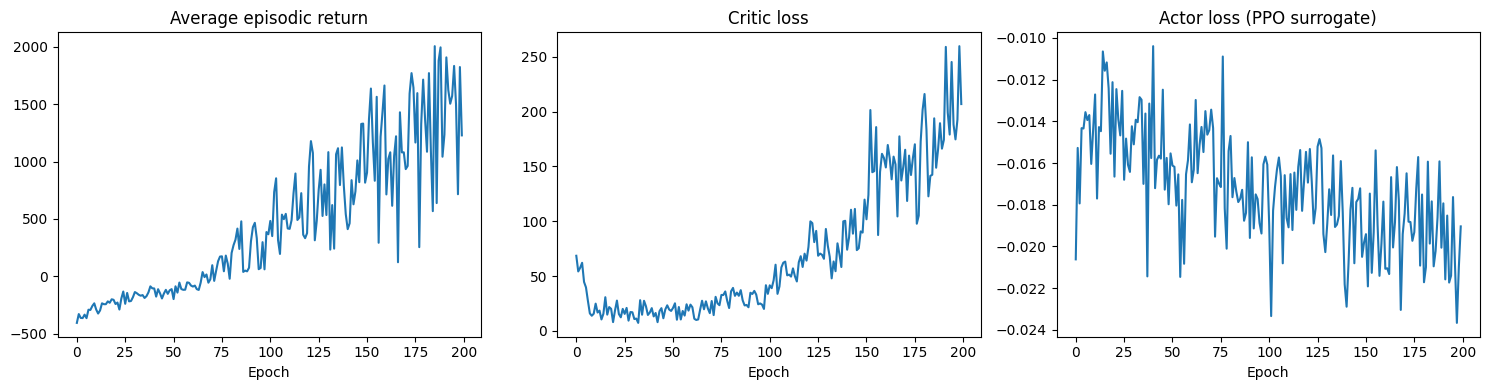

Running basic k=0 at 1000 epochs:

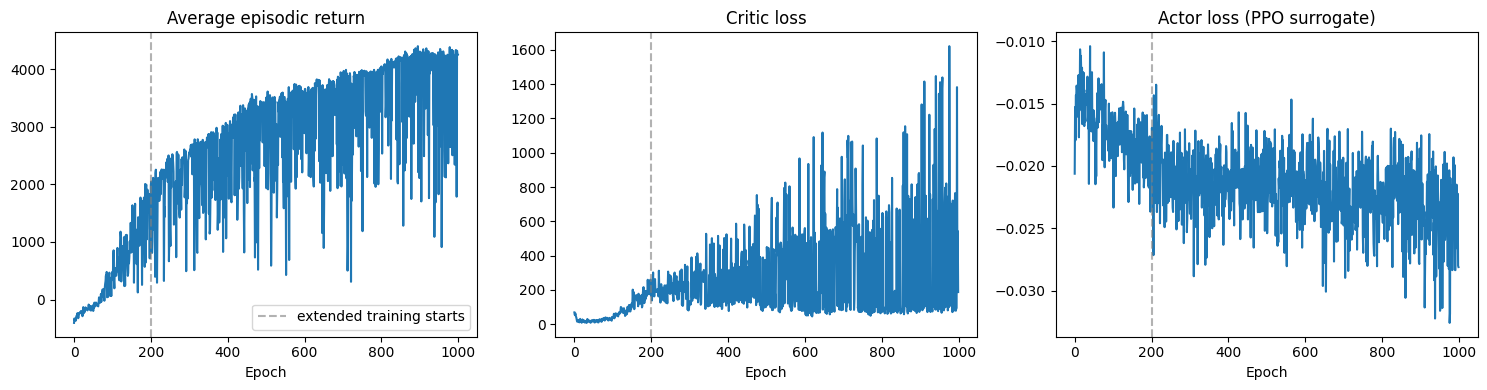

Running with w-conditioning at 200 epochs:

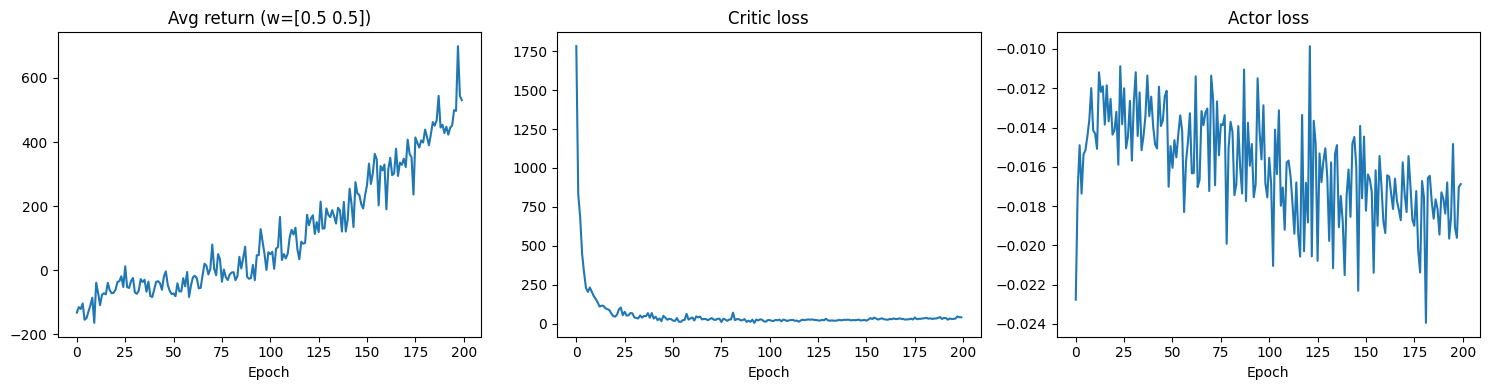